# Session 3: Image Analysis — Band Arithmetic and Spectral Indices
**MOOC Series: From Satellite Data to Insights with Digital Earth Sweden**

---

## Session outline

- Introduction to spectral indices: why combining bands is powerful
- Computing NDVI using band arithmetic (manual formula)
- Computing NDVI using the built-in openEO method
- Visualizing and interpreting an NDVI map

By the end of this session you will have produced your first quantitative analysis layer — an NDVI map of Karlstad — and learned how to interpret what it tells you about vegetation cover.

---

## 1. Setup

In [1]:
import openeo
import io
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import rasterio
import rasterio.plot

# Connect to Digital Earth Sweden
connection = openeo.connect('https://openeo.digitalearth.se')
connection.authenticate_basic(username='testuser', password='secretpassword')

# Area of interest: Karlstad, Sweden
aoi = {
    'west':  13.460930954751282,
    'east':  13.585449709728213,
    'south': 59.36327761288911,
    'north': 59.40107161575003,
    'crs':   'EPSG:4326',
}
timespan = ['2026-06-01', '2026-07-01']

# Load Sentinel-2 datacube with Red and NIR bands
datacube = connection.load_collection(
    collection_id='des_s2_msi_l2a',
    spatial_extent=aoi,
    temporal_extent=timespan,
    bands=['B02', 'B03', 'B04', 'B08'],
    properties = {'eo:cloud_cover': lambda x: x <= 20},
)
image = datacube.reduce_dimension(dimension='t', reducer='first')

print('Connected and datacube defined.')

Connected and datacube defined.


Visualize image as learned in Session 2 to have a visual reference for the NDVI interpretation.

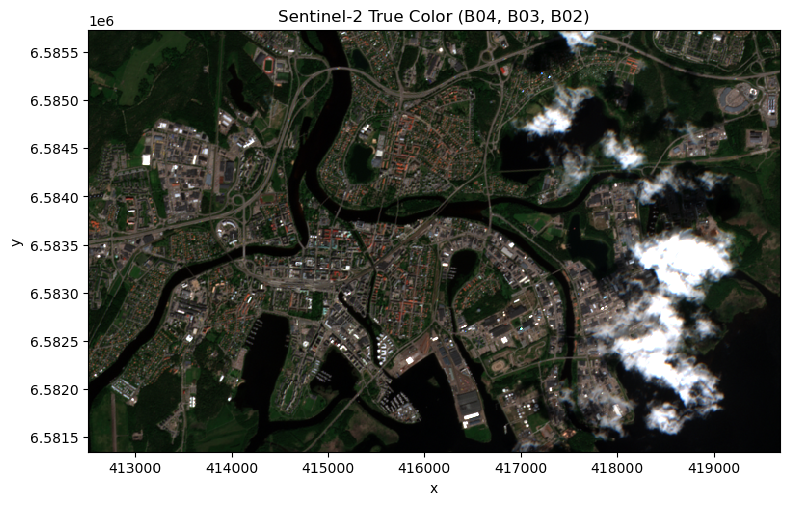

In [2]:
image = datacube.reduce_dimension(dimension='t', reducer='first')

# Downloading the image as GeoTIFF
image_tif = image.download(format='GTiff')

# Load into xarray
da = xr.open_dataarray(io.BytesIO(image_tif), engine='rasterio')
da = da.assign_coords(band=['B02', 'B03', 'B04', 'B08'])
da = (da.astype(np.float32) / 10_000).clip(0, 1)

# True color visualization
rgb = da.sel(band=['B04', 'B03', 'B02'])
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
rgb.plot.imshow(rgb='band', vmin=0, vmax=0.4, ax=ax)
ax.set_aspect('equal')
ax.set_title('Sentinel-2 True Color (B04, B03, B02)')
plt.tight_layout()
plt.show()

## 2. Why spectral indices?

Each spectral band records how strongly the Earth's surface reflects light at a particular wavelength. Different materials have characteristic **spectral signatures** — they reflect and absorb different wavelengths in distinctive ways.

| Surface type | Blue (B02) | Green (B03) | Red (B04) | NIR (B08) |
|---|---|---|---|---|
| Healthy vegetation | Low | Medium | **Low** (absorbs red) | **High** (reflects NIR) |
| Water | Medium | Low | Low | Very low |
| Urban / bare soil | Medium | Medium | Medium | Medium |
| Snow | High | High | High | Medium |

A **spectral index** is a mathematical ratio or combination of bands designed to amplify the contrast between surface types. Instead of looking at one band, indices combine two or more bands to produce a single number that is more diagnostic than any individual band.

The most widely used index for vegetation is the **Normalized Difference Vegetation Index (NDVI)**.

## 3. The Normalized Difference Vegetation Index (NDVI)

NDVI exploits the strong contrast in how healthy plants interact with red and near-infrared light:

- Plants **absorb** red light (via chlorophyll) for photosynthesis → low Red reflectance.
- Plants **reflect** near-infrared light strongly (cell structure) → high NIR reflectance.
- Non-vegetated surfaces (soil, urban) reflect red and NIR more similarly.

The formula normalizes this difference:

$$
\text{NDVI} = \frac{\text{NIR} - \text{Red}}{\text{NIR} + \text{Red}} = \frac{B08 - B04}{B08 + B04}
$$

The normalization (dividing by the sum) keeps the result in the range **\[−1, +1\]** regardless of illumination conditions:

| NDVI range | Interpretation |
|---|---|
| 0.4 – 1.0 | Dense, healthy vegetation (forests, crops) |
| 0.2 – 0.4 | Sparse or stressed vegetation, grassland |
| 0.0 – 0.2 | Bare soil, rock, sand |
| −0.1 – 0.0 | Urban surfaces, gravel |
| < −0.1 | Water, snow, ice |

## 4. Computing NDVI with band arithmetic

openEO supports Python's native arithmetic operators on datacube objects. A subtraction like `nir - red` is automatically translated by the openEO client into the corresponding backend process — it does not execute locally in Python.

This is a powerful feature: you can write natural mathematical expressions and they are executed at scale on the backend.

In [3]:
# Extract individual bands from the datacube
red = image.band('B04')  # Red (665 nm)
nir = image.band('B08')  # Near-infrared (842 nm)

# Compute NDVI using the standard formula
# Note: these operations are translated to backend processes, not computed locally
ndvi = (nir - red) / (nir + red)

# Download the result as a GeoTIFF
ndvi_tif = ndvi.download(format='GTiff')
print('NDVI downloaded successfully.')

NDVI downloaded successfully.


## 5. Visualizing the NDVI map

We use the `RdYlGn` colormap (Red → Yellow → Green) which is a natural choice for NDVI:
- **Green** → high NDVI → dense vegetation
- **Yellow** → medium NDVI → sparse vegetation or mixed surfaces
- **Red** → low or negative NDVI → water, urban, bare surfaces

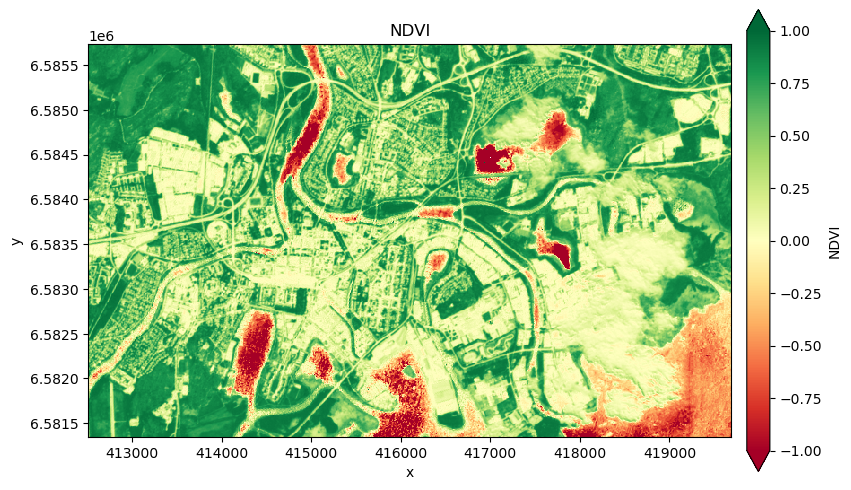

In [4]:
ndvi_da = xr.open_dataarray(io.BytesIO(ndvi_tif), engine='rasterio')
ndvi_da = ndvi_da.squeeze()  # Drop any singleton band dimension

# Formatting the colorbar to look 'nicer'
cbar_kwargs={'shrink': 0.6, 'aspect': 20, 'pad': 0.02, 'label': 'NDVI'}

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ndvi_da.plot.imshow(ax=ax, cmap='RdYlGn', cbar_kwargs=cbar_kwargs, vmin=-1, vmax=1)
ax.set_aspect('equal')
ax.set_title('NDVI')
plt.show()

## 6. Using the built-in `.ndvi()` method

openEO also provides a convenient built-in process for NDVI via the `.ndvi()` method. This is shorter to write and uses the same formula under the hood. The result should be identical to the manual calculation above.

This example also illustrates a broader point: the same syntax computes NDVI for every image in the datacube, regardless of how many time steps or scenes it contains.

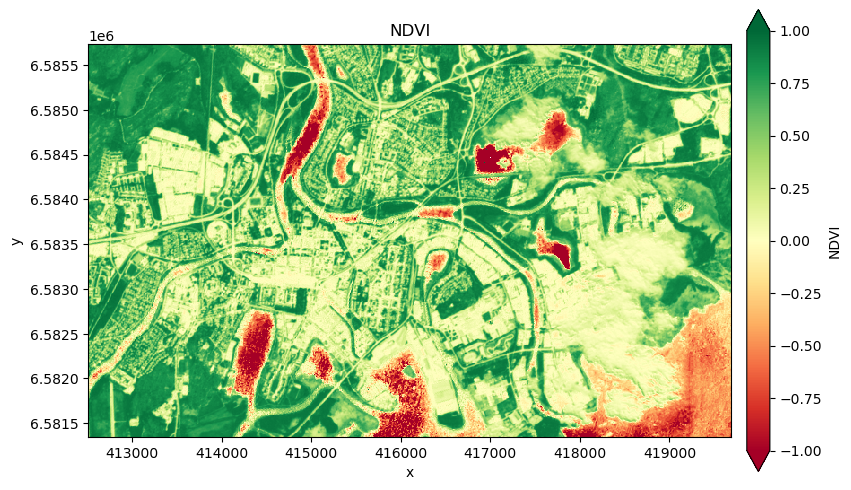

In [5]:
# Compute NDVI using the built-in openEO method
ndvi_datacube = datacube.ndvi(nir='B08', red='B04')
ndvi = ndvi_datacube.reduce_dimension(dimension='t', reducer='first')

# Download and display
ndvi_tif = ndvi.download(format='GTiff')
ndvi_da = xr.open_dataarray(io.BytesIO(ndvi_tif), engine='rasterio')
ndvi_da = ndvi_da.squeeze()  # Drop any singleton band dimension

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ndvi_da.plot.imshow(ax=ax, cmap='RdYlGn', cbar_kwargs=cbar_kwargs, vmin=-1, vmax=1)
ax.set_aspect('equal')
ax.set_title('NDVI')
plt.show()

## 7. Interpreting the NDVI map

Take a moment to look at the NDVI map you produced and relate it to the true-color image.

- The **dark green** areas in the NDVI map correspond to forested zones south and east of the city.
- The **city centre** shows lower NDVI values (yellow/orange) — mostly paved surfaces and buildings with occasional small parks.
- The **lake** (Lake Vänern to the south) shows very low or negative NDVI — water absorbs NIR strongly.
- The **seasonal context** matters: this image is from June, so deciduous trees have their leaves. NDVI values for forests are higher than in the fall/winter.
- There are **artefacts** from the clouds, clearly visible in some areas. 

NDVI is the core feature we will use in Session 6 to train a machine learning model that automatically maps urban green areas.

---

## Summary

In this session you:

- Understood why spectral indices are more powerful than individual bands.
- Learned the NDVI formula and its physical basis in vegetation optics.
- Computed NDVI two ways: using manual band arithmetic and using the built-in `.ndvi()` method.
- Visualized and interpreted an NDVI map over Karlstad.

**Next session:** we zoom out from a single image and explore how multi-temporal datacubes work — and how to reduce the time dimension into a single summary layer.

---
*Digital Earth Sweden MOOC — Session 3 of 6*